In [1]:
!pip install langchain langchain_core langchain_groq langchain_community langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [langchain_groq]


In [2]:
import os
from langgraph.graph import StateGraph,START,END
from typing import TypedDict, Annotated,List
from langchain_core.messages import HumanMessage,AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display,Image

In [3]:
class PlannerState(TypedDict):
    messages:Annotated[List[HumanMessage | AIMessage],"the message in the conversation"]
    city:str
    interest:list[str]
    itinerary:str


In [4]:
from langchain_groq import ChatGroq
llm=ChatGroq(
    temperature=0,
    groq_api_key="",
    model_name= "llama-3.3-70b-versatile"
)
result=llm.invoke("What is multi AI Agent")
result.content

'A multi-agent system is a system composed of multiple autonomous agents that interact with each other and their environment to achieve a common goal or set of goals. In the context of artificial intelligence (AI), a multi-agent system is a collection of AI agents that work together to solve a problem or complete a task.\n\n**Key characteristics of multi-agent systems:**\n\n1. **Autonomy**: Each agent has its own goals, behaviors, and decision-making processes.\n2. **Interactions**: Agents interact with each other and their environment to achieve their goals.\n3. **Distributed problem-solving**: Agents work together to solve a problem or complete a task.\n4. **Decentralized control**: There is no centralized controller; instead, agents make decisions based on their local knowledge and interactions.\n\n**Types of multi-agent systems:**\n\n1. **Cooperative multi-agent systems**: Agents work together to achieve a common goal.\n2. **Competitive multi-agent systems**: Agents compete with ea

In [8]:
Itinerary_prompt=ChatPromptTemplate.from_messages([
    """("system," "You are a helpful travel assisstant. Create a day trp itenary for {city}based on the user's interest :{interest}. Provide a brief bullated itinerary."),
    ("human", "Create an itinerary for my day trip"),"""
])

In [19]:
def input_city(state: PlannerState)-> PlannerState:
    print("Please enter the city you wish to travel")
    user_messages = input("user_input: ")
    return {
        **state,
        "city": user_messages,
        "messages":state["messages"] + [HumanMessage(content=user_messages)]
    }
def input_interest(state:PlannerState)->PlannerState:
    print("Please enter the interest for the trip to :{state['city']} (comma-saperated):")
    user_messages = input("user_input: ")
    return {
        **state,
        "interest":[interest.strip()for interest in user_messages.split(",")],
        "messages":state["messages"] + [HumanMessage(content=user_messages)]
    }

def input_itinerary(state:PlannerState)->PlannerState:
    print(f"create an itinerary for {state["city"]}:based on interest:(",".join(state['interest'])}")
    response = llm.invoke(Itinerary_prompt.format_messages(city=state,interest=",".join(state['interest'])))
    print("\nFinal Itinerary:")
    print(response.content)
    return{
        **state,
        "messages":state["messages"] + [AIMessage(content=response.content)],
        "itinerary":response.content,
    }




In [20]:
workflow= StateGraph(PlannerState)
workflow.add_node("input_city",input_city)
workflow.add_node("input_interest",input_interest)
workflow.add_node("input_itinerary", input_itinerary)
workflow.set_entry_point("input_city")

workflow.add_edge("input_city","input_interest")
workflow.add_edge("input_interest","input_itinerary")
workflow.add_edge("input_itinerary",END)

app= workflow.compile()

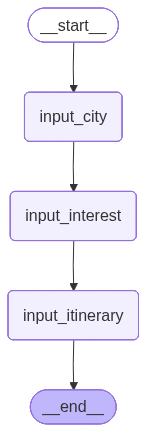

In [21]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API
        )
    )
)

In [22]:
def travel_planner(user_request:str):
    print(f"Initial request: {user_request}\n")
    state={
        "messages":[HumanMessage(content=user_request)],
        "city":"",
        "interest":[],
        "itinerary":"",
    }
    for output in app.stream(state):
        pass

In [23]:
user_request= "I want to plan a day trip"
travel_planner(user_request)

Initial request: I want to plan a day trip

Please enter the city you wish to travel
Please enter the interest for the trip to :{state['city']} (comma-saperated):
create an itinerary for america:based on interest:( .join(state['interest'])}

Final Itinerary:
Based on your interests, I've created a day trip itinerary for you. Since you've mentioned multiple locations across the country, I'll provide a few options for different regions. Here's a brief bulleted itinerary for each location:

**Option 1: Disneyland, California**
* 9:00 AM: Arrive at Disneyland and start your day at the iconic Sleeping Beauty Castle
* 10:00 AM: Explore the different themed lands, such as Adventureland and Fantasyland
* 1:00 PM: Take a break for lunch at one of the many restaurants within the park
* 2:30 PM: Watch a parade or show, such as the Mickey's Soundsational Parade
* 5:00 PM: End your day with the nighttime spectacular, Disneyland Forever

**Option 2: Tennessee**
* 9:00 AM: Visit the Great Smoky Mount